Решение задачи бинарной классификации с помощью функции потерь

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def loss(x, y, w):
    return np.sign(np.dot(x, w)) * y < 1.0

In [3]:
data = []

with open("train.csv") as csv:
    while line := csv.readline():
        data.append(list(map(lambda x: x.strip(), line.split(";"))))

In [4]:
w = np.array([0, -1], dtype="float")

graph_x, graph_y = [], []

N = 100
S = 0.5

In [5]:
for _ in range(N):
    q = 0
    
    for x1, x2, name in data:
        y = -1 if name == "caterpillar" else 1

        x = np.array([int(x1), int(x2)])

        graph_x.append(x[0])
        graph_y.append(x[1])

        if loss(x, y, w):
            w[0] += S * y
            q += 1

    if q == 0:
        break

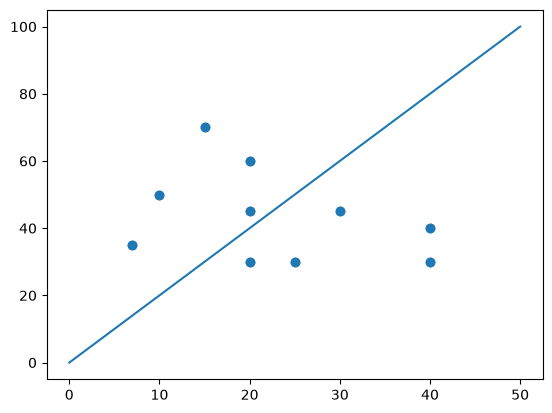

In [6]:
plt.scatter(graph_x, graph_y)

x = np.linspace(0, 50, 2)
y = -w[0] / w[1] * x
plt.plot(x, y)

Решение задачи бинарной классификации через МНК

In [8]:
data = []

with open("train.csv") as csv:
    while line := csv.readline():
        data.append(list(map(lambda x: x.strip(), line.split(";"))))

In [9]:
graph_x, graph_y = [], []

xs, ys = [], []

for x1, x2, name in data:
    xs.append([1.0, float(x1), float(x2)])
    ys.append(1.0 if name == "caterpillar" else -1.0)

    graph_x.append(int(x1))
    graph_y.append(int(x2))

In [10]:
x = np.matrix(xs, dtype="float")
y = np.matrix(ys, dtype="float")

w = (x.T @ x).I @ (x.T @ y.T)

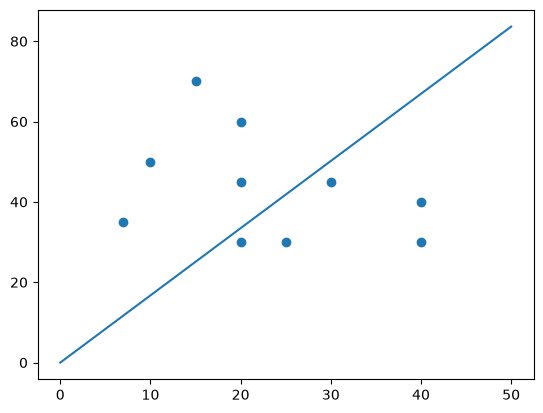

In [11]:
plt.scatter(graph_x, graph_y)

x = np.linspace(0, 50, 2)
y = -(w[1, 0] / w[2, 0]) * x
plt.plot(x, y)

Решение задачи бинарной классификации с помощью сигмоиды в качестве функции потерь и с использованием скорости забывания

In [13]:
def sigmoid(w, x, y):
    return 2.0 / (1.0 + np.exp(np.dot(w, x) * y))

def sigmoid_prime(w, x, y):
    e = np.exp(np.dot(w, x) * y)
    return -2.0 / ((1.0 + e) ** 2) * e * np.dot(x, y)

In [14]:
data = []

with open("train.csv") as csv:
    while line := csv.readline():
        data.append(list(map(lambda x: x.strip(), line.split(";"))))

In [15]:
graph_x, graph_y = [], []
xs, ys = [], []

start_loss_sum = 0
w_start = np.array([0.0, 0.0])

In [16]:
for x1, x2, name in data:
    y = 1.0 if name == "caterpillar" else -1.0

    x = np.array([float(x1), float(x2)])

    xs.append(x)
    ys.append(y)

    start_loss_sum += sigmoid(w_start, x, y)

    graph_x.append(int(x1))
    graph_y.append(int(x2))

In [17]:
x = np.linspace(0, 50, 2)

In [18]:
def solve(rate, decay):
    N = 500
    w = np.array([0.0, 0.0])
    qualities = [start_loss_sum / len(data)]

    for _ in range(N):
        quality = 0.0

        for i in range(len(data)):
            loss = sigmoid(w, xs[i], ys[i])
            w -= rate * sigmoid_prime(w, xs[i], ys[i])
            quality = decay * loss + (1.0 - decay) * quality

        qualities.append(quality)

        if quality < 0.001:
            break

    plt.plot([i for i in range(len(qualities))], qualities)
    plt.show()

    plt.scatter(graph_x, graph_y)

    y = -(w[0] / w[1]) * x

    plt.plot(x, y)

    plt.show()

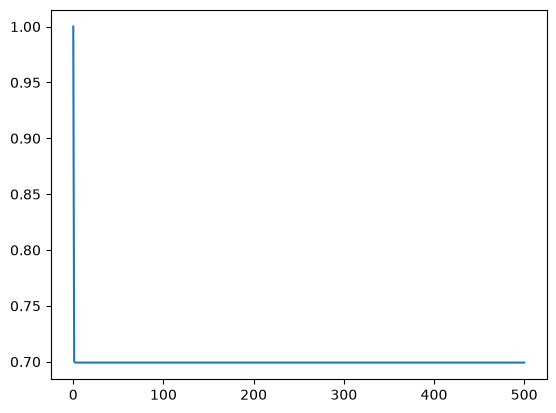

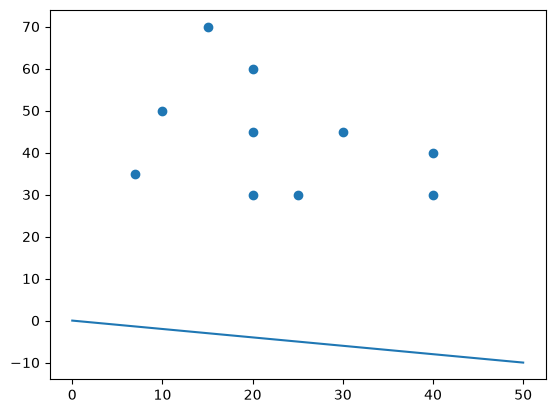

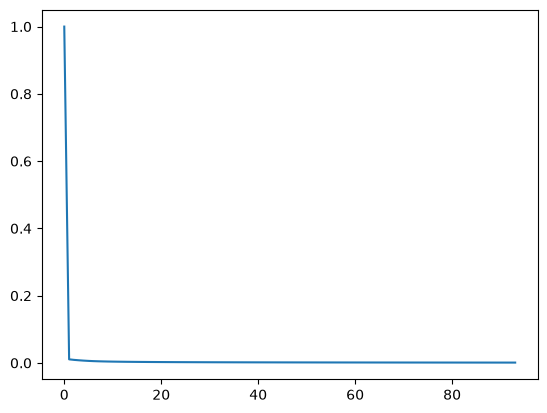

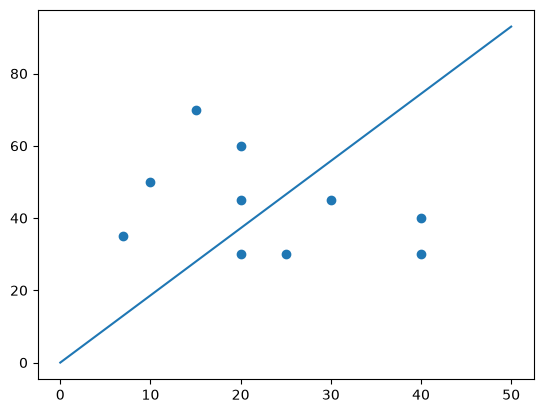

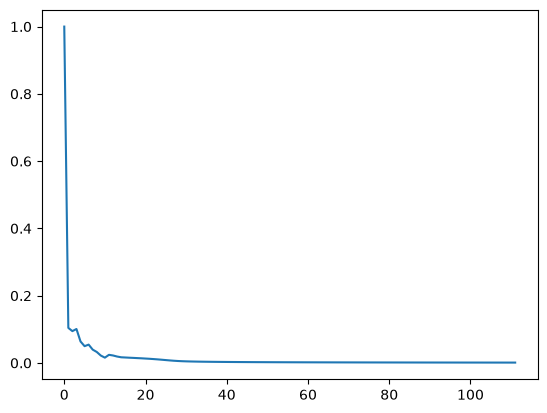

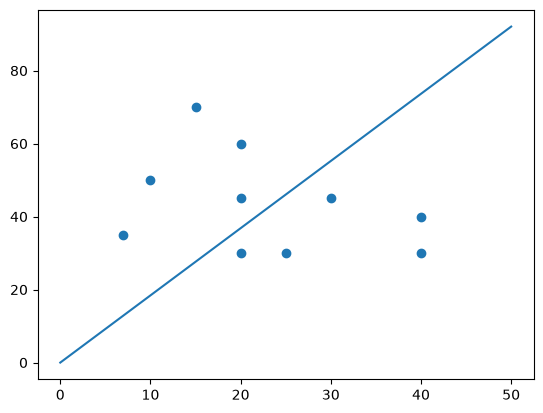

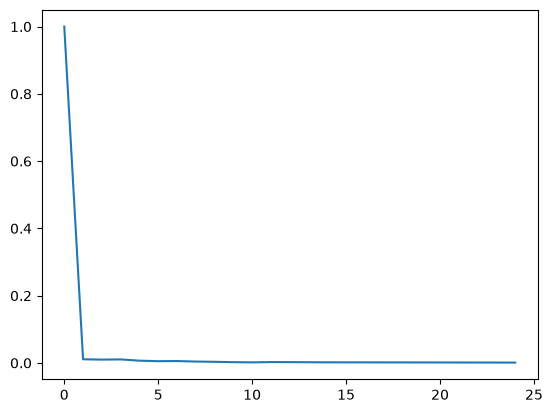

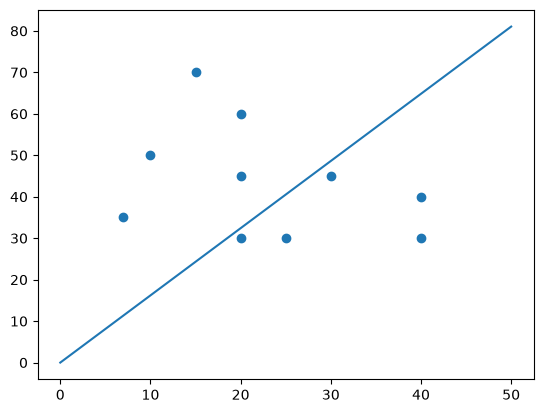

In [19]:
solve(0.05, 0.5)
solve(0.0005, 0.001)
solve(0.005, 0.01)
solve(0.005, 0.001)